In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import janitor
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [ ]:
# Ruta de los archivos

nombre_df = "02_train_tablon_calidad.pkl"
ruta_proyecto = "../02_datos/03_Entrenamiento/"
ruta_cat = ruta_proyecto + "02b_cat_resultado_calidad.pkl"
ruta_num = ruta_proyecto + "02c_num_resultado_calidad.pkl"

In [ ]:
# Cargamos los datos

df = pd.read_pickle(ruta_proyecto + nombre_df)
cat = pd.read_pickle(ruta_cat)
num = pd.read_pickle(ruta_num)

print("✅ Dataframe 'df' exportado correctamente")
print("✅ Dataframe 'cat' exportado correctamente")
print("✅ Dataframe 'num' exportado correctamente")

✅ Dataframe 'df' exportado correctamente
✅ Dataframe 'cat' exportado correctamente
✅ Dataframe 'num' exportado correctamente


# 01. EDA - Variables categóricas
---

## 1.1. Análisis de variables

In [4]:
def frecuencias_cat(df_cat):
    resultado = df_cat.apply(lambda x: x.value_counts(normalize = True)).T.stack() \
                .to_frame().reset_index()\
                .rename(columns = {'level_0':'Variable', 'level_1':'Valor', 0:'Frecuencia'}) \
                .sort_values(by=['Variable', 'Frecuencia'])
    
    return(resultado)

In [5]:
frecuencias_cat(cat)

,Variable,Valor,Frecuencia
182,ambito,Healthcare Management,0.021
185,ambito,International Business,0.023
200,ambito,Travel and Tourism,0.025
189,ambito,Media and Advertising,0.028
171,ambito,"Banking, Investment And Insurance",0.044
...,...,...,...
165,ult_actividad,Supply Chain Management,NaN
166,ult_actividad,Travel and Tourism,NaN
167,ult_actividad,Unemployed,NaN
168,ult_actividad,Working Professional,NaN


Se analiza rápidamente las variables y se observa que las personas que indican en "conociste_google" nos pusieron "OTROS" y solo es 0.001%. Estas no tienen mucho sentido, por lo que, se podrían eliminar.

- **Eliminar las variables de `conociste_google`**
- Como estamos trabajando en un proyecto de contactar a Leads, se **eliminan aquellos que han seleccionado `no_enviar_email`= `'Yes'`**
- Eliminamos `Email Bounced` ya que son emails rebotados y que no nos interesan porque no podremos contractarla. Si no se puede contactar, no se gestionará.

Filtramos el dataset con lo que nos queremos quedar.

In [6]:
cat.shape

(5317, 12)

In [7]:
cat = cat.loc[(cat['no_llamar'] != 'OTROS') & (cat['no_enviar_email'] != 'Yes') & (cat['ult_actividad'] != 'Email Bounced') \
        .drop(columns=[
            'conociste_facebook',
            'conociste_google',
            'conociste_periodico',
            'conociste_referencias',
            'no_enviar_email',
            'no_llamar'
        ])]

cat.head()

,origen,fuente,no_enviar_email,no_llamar,ult_actividad,ambito,ocupacion,conociste_google,conociste_periodico,conociste_facebook,conociste_referencias,descarga_lm
id,,,,,,,,,,,,
630952,Landing Page Submission,Google,No,No,Email Opened,Human Resource Management,Unemployed,No,No,No,No,No
633132,API,Chat,No,No,Chat Conversation,Select,Unemployed,No,No,No,No,No
636677,Landing Page Submission,Google,No,No,SMS Sent,Operations Management,Unemployed,No,No,No,No,No
601564,API,Chat,No,No,Email Opened,Select,Student,No,No,No,No,No
645378,Landing Page Submission,Google,No,No,OTROS,IT Projects Management,Unemployed,No,No,No,No,No


Como hemos eliminado los registros en el dataset de categóricas, **vamos a eliminarlos en el numérico, para igualar datasets**, ya que sino podría no cuadrarse entre ellos. Ya que sino, rellenará las *variables categóricas con nulos*. Lo elimino a través del índice, diciendo que aquellos id que aparecen en `cat` se eliminarán en `num`.

In [8]:
num = num[num.index.isin(cat.index)]
num.head()

,compra,visitas_total,tiempo_en_site_total,paginas_vistas_visita,score_actividad,score_perfil
id,,,,,,
630952,0,4,1221,4.000,14.000,16.000
633132,0,0,0,0.000,14.000,16.000
636677,1,4,963,4.000,14.000,18.000
601564,0,0,0,0.000,14.000,16.000
645378,0,3,172,3.000,10.000,13.000


In [ ]:
# Confirmamos que tienen mismos registros 

print(cat.shape)
print(num.shape)

(4837, 12)
(4837, 6)


## 1.2. Análisis gráfico

In [10]:
def graficos_eda_categoricos(cat):
    
    # 1. Se calcula el número de filtas que se necesita
    from math import ceil
    filas = ceil(cat.shape[1]/2)

    # 2. Definimos el grafico
    f, ax = plt.subplots(nrows=filas, ncols=2, figsize=(16, filas * 6))

    # 3. Aplanamos para iterar por el gráfico como si fuera 1 dimensión y no 2.
    ax = ax.flat

    # 4. Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(cat):
        
        cat[variable].value_counts().plot.barh(ax = ax[cada])
        
        ax[cada].set_title(variable, fontsize=12, fontweight='bold')
        ax[cada].tick_params(labelsize=12)

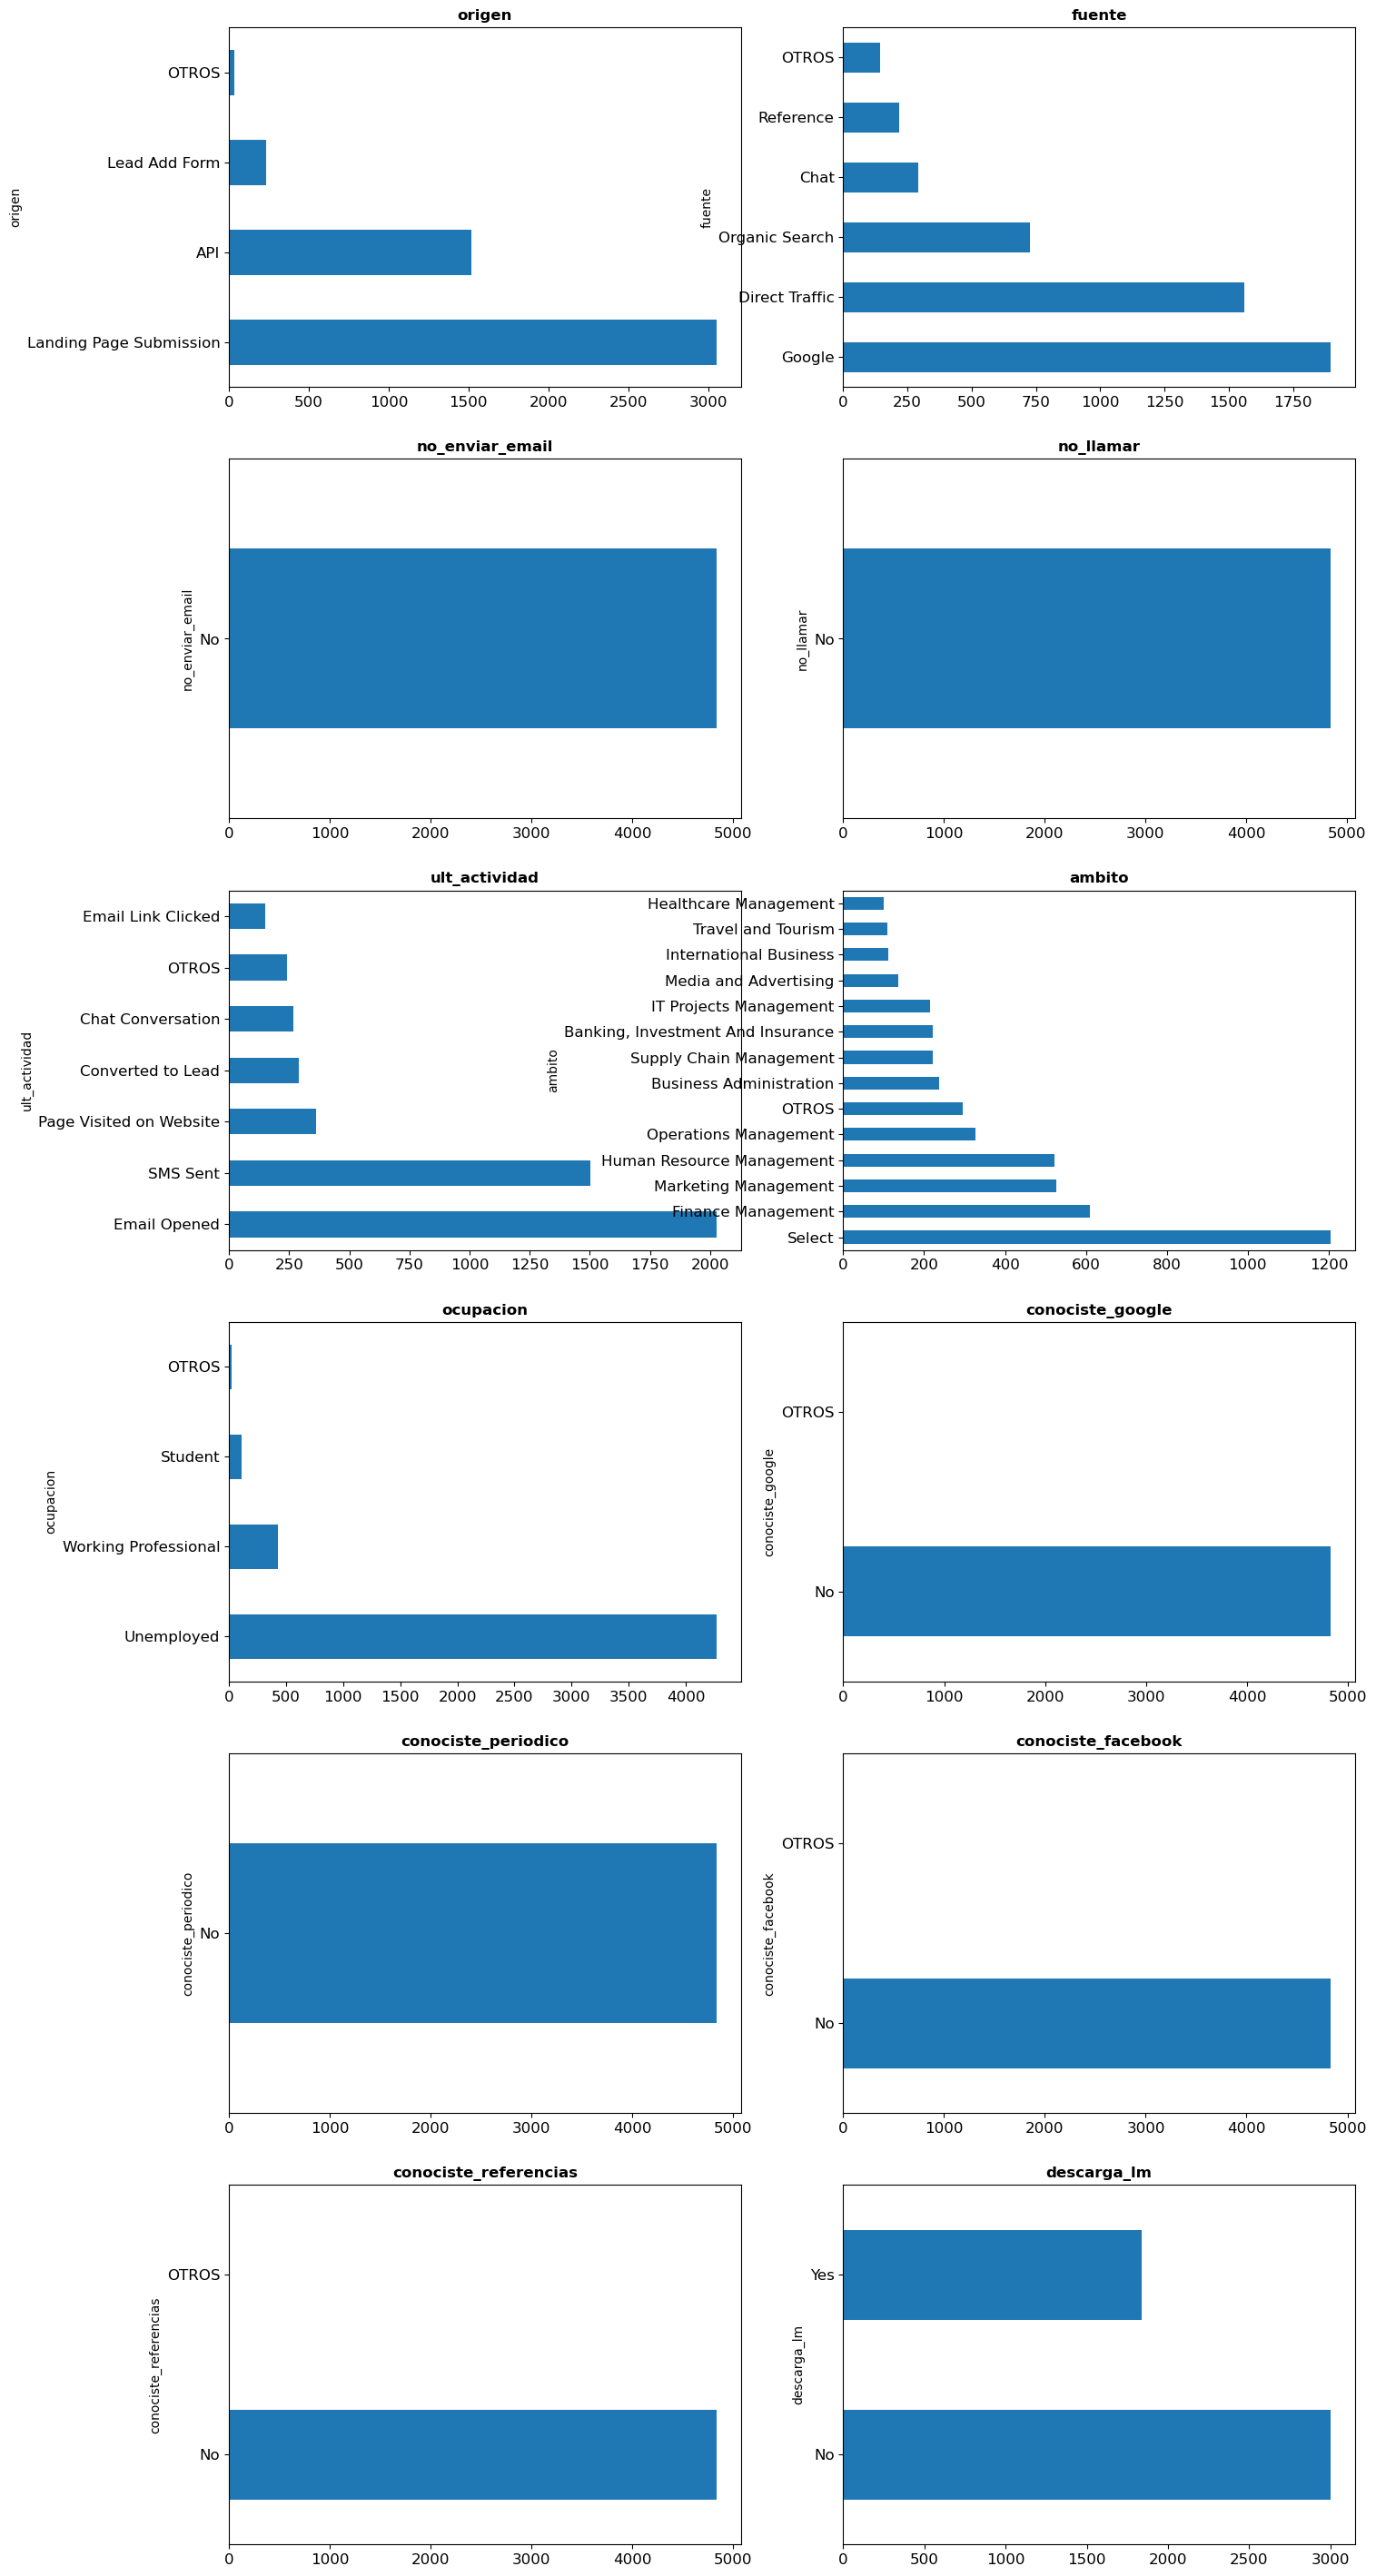

In [11]:
graficos_eda_categoricos(cat)

Se observa lo siguiente:
- La mayoría de los perfiles que se observan son desempleados, ¿la empresa se enfoca en este tipo de perfil? Ya que deberían tener menos perfil adquisitivo
- La mayoría proceden de Landing page y de fuente Google
- Casi el 50% descarga el lead magnet

# 02. EDA - Variables numéricas
---

## 2.1. Análisis numérico

In [17]:
def estadisticos_cont(df_num):

    # Calculamos describe
    estadisticos = num.describe().T

    # Añadimos mediana
    estadisticos['mediana'] = num.median()

    # Reordenamos para que la mediana esté al lado de la media
    estadisticos.iloc[:, [0, 1, 8, 2, 3, 4, 5, 6, 7]]

    # Lo devolvemos
    return(estadisticos)

In [18]:
estadisticos_cont(num)

,count,mean,std,min,25%,50%,75%,max,mediana
compra,4837.000,0.415,0.493,0.000,0.000,0.000,1.000,1.000,0.000
visitas_total,4837.000,4.160,4.872,0.000,2.000,3.000,5.000,251.000,3.000
tiempo_en_site_total,4837.000,607.258,556.635,0.000,133.000,368.000,1099.000,2272.000,368.000
paginas_vistas_visita,4837.000,2.869,1.913,0.000,2.000,2.500,4.000,24.000,2.500
score_actividad,4837.000,14.062,0.946,7.000,14.000,14.000,14.000,18.000,14.000
score_perfil,4837.000,16.297,1.425,11.000,16.000,16.000,17.000,20.000,16.000


Se observa lo siguiente:

- **No existe un desbalance severo** (existe un un 41,5% en la target (compra) 1/0), por lo que, no se necesita SMOTE u oversampling agresivo, aunque es recomendable verificar con métricas como F1 o AUC-ROC en lugar de accuracy.
- `compra`: de los 4837, solo entorno al 25% compra (el Q75 = 1).
- `visitas_total`: teniendo una media de 4,16 pero max 251 indica que la distancia entre Q75 y el máximo podrían haber outliers.
- `tiempo_en_site_total`: la media (607 segundos) es muy superior a la mediana (368 segundos), por lo que, es una distribución fuertemente sesgada a la derecha, un pequeño grupo pasa mucho tiempo. Recomendamos *log-transform*.
- `paginas_vistas_visita`: entre el Q75 y el max existe una serie del std de 10 veces, por lo que podría haber outliers.
- `score_actividad` y `score_perfil`: parecen estar bien, ya que como decíamos parece venir calculado del CRM/ERP que proporciona los datos.

## 2.2. Análisis gráfico

In [30]:
def graficos_eda_continuas(num):
    # Calculamos el numero de fila que necesitamos
    from math import ceil
    filas = ceil(num.shape[1]/2)

    # Definimos el gráfico
    f, ax = plt.subplots(nrows=filas, ncols=2, figsize=(16, filas*6))

    # Aplanamos para iterar por el gráfico coom si fuera de 1 dimensión en lugar de 2
    ax = ax.flat

    # Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(num):
        num[variable].plot.density(ax=ax[cada])
        ax[cada].set_title(variable, fontsize=12, fontweight="bold")
        ax[cada].tick_params(labelsize=12)

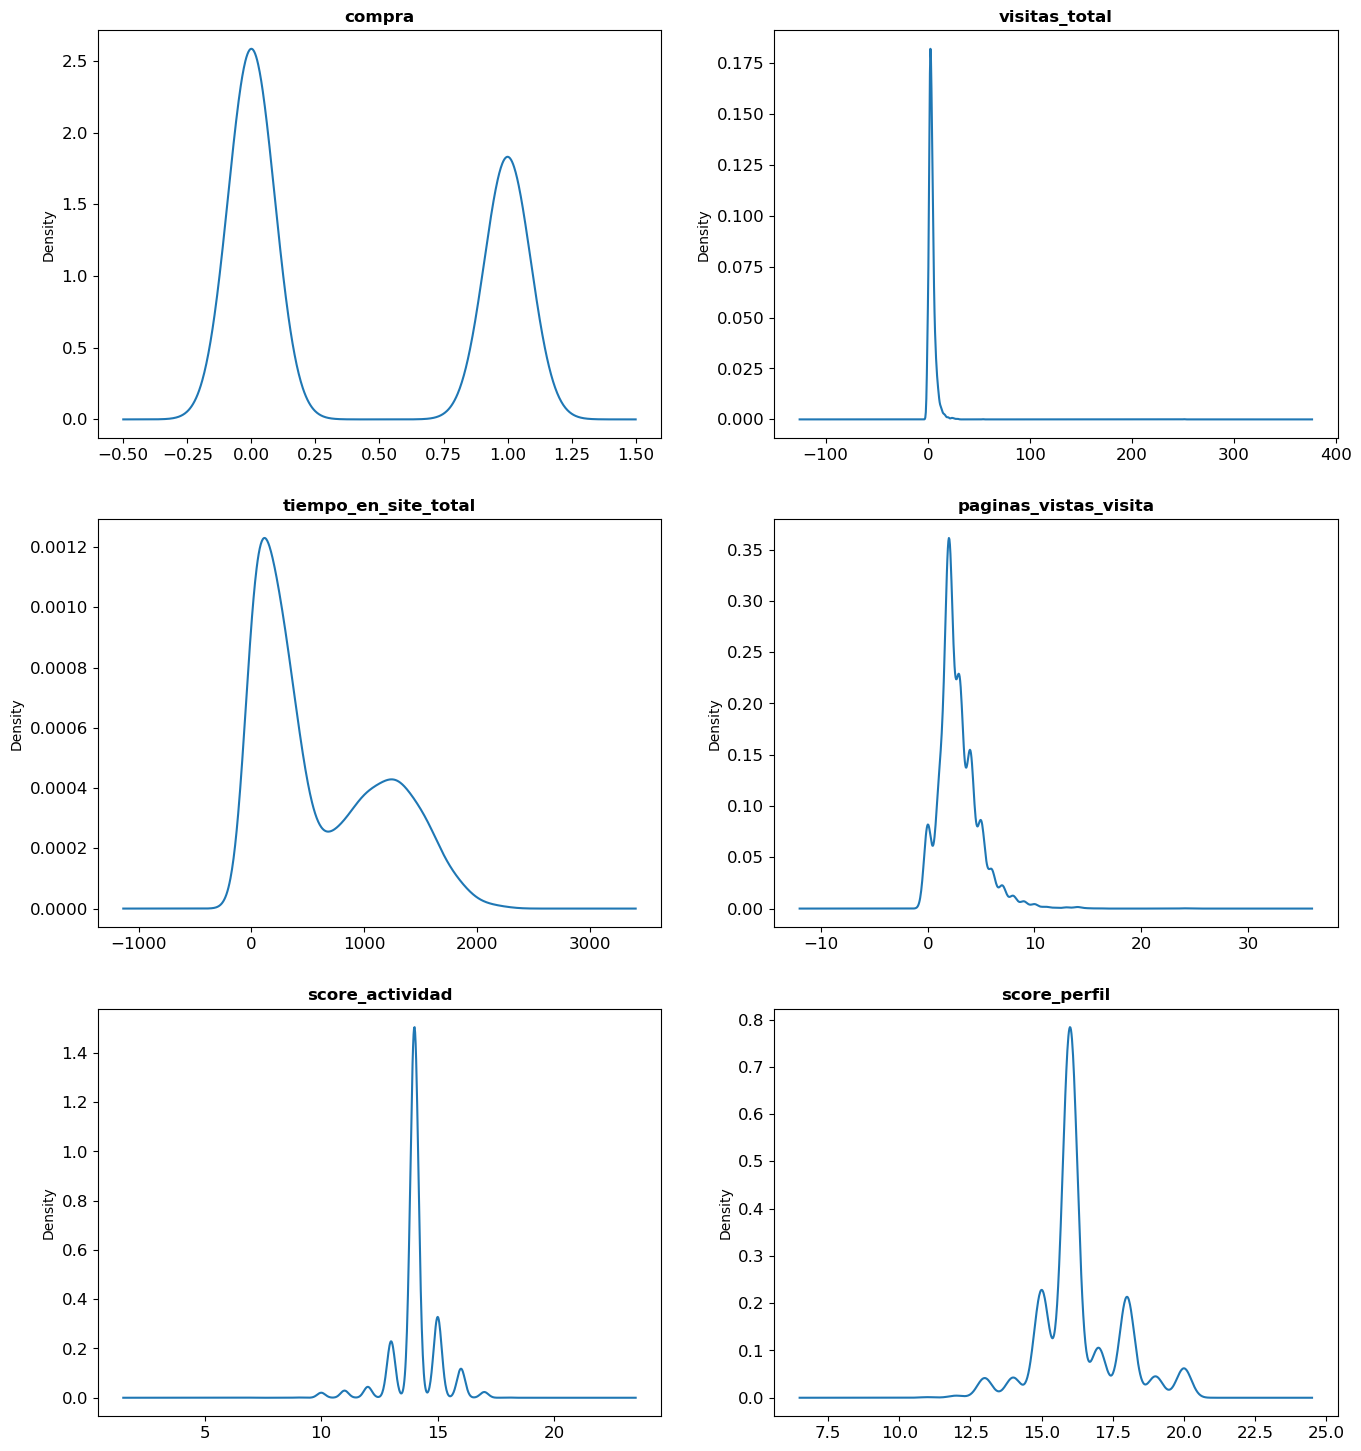

In [31]:
graficos_eda_continuas(num)

- Vemos que `tiempo_site_total` sigue una distribución bimodal (2 distribuciones)
- Las demás variables **siguen la Distribución Normal** (salvando las distancias que existen en la realidad), por lo que, es probable que no se usen variables de normalización.

# 3. Guardamos datasets tras calidad de datos
---

Guardamos los avances en cat y num con sun sufijo para poder guardar o recuèrar avances del proyecto. 

En **formato pickle** para no perder las modificaciones de metadatos. 

In [1]:
# Guardamos los datos

cat.to_pickle(ruta_proyecto + "03_cat_resultado_eda.pkl")
num.to_pickle(ruta_proyecto + "03_num_resultado_eda.pkl")

print("✅ Dataframe 'cat' exportado correctamente")
print("✅ Dataframe 'num' exportado correctamente")

NameError: name 'cat' is not defined